## 🎯 MILPRouter example

This notebook demonstrates how to use `OptiWindNet` to design collector system cable networks using the **MILPRouter with OR-Tools Solver**.

### Load data

import required modules

In [1]:
from optiwindnet.api import WindFarmNetwork, EWRouter, MILPRouter

In [2]:
# Display figures as SVG in Jupyter notebooks
%config InlineBackend.figure_formats = ['svg']

create an instance of `wfn` using `.from_pbf()`


In [3]:
wfn = WindFarmNetwork.from_pbf(filepath='data/DTU_letters.osm.pbf', cables=[(7, 2000.0)])

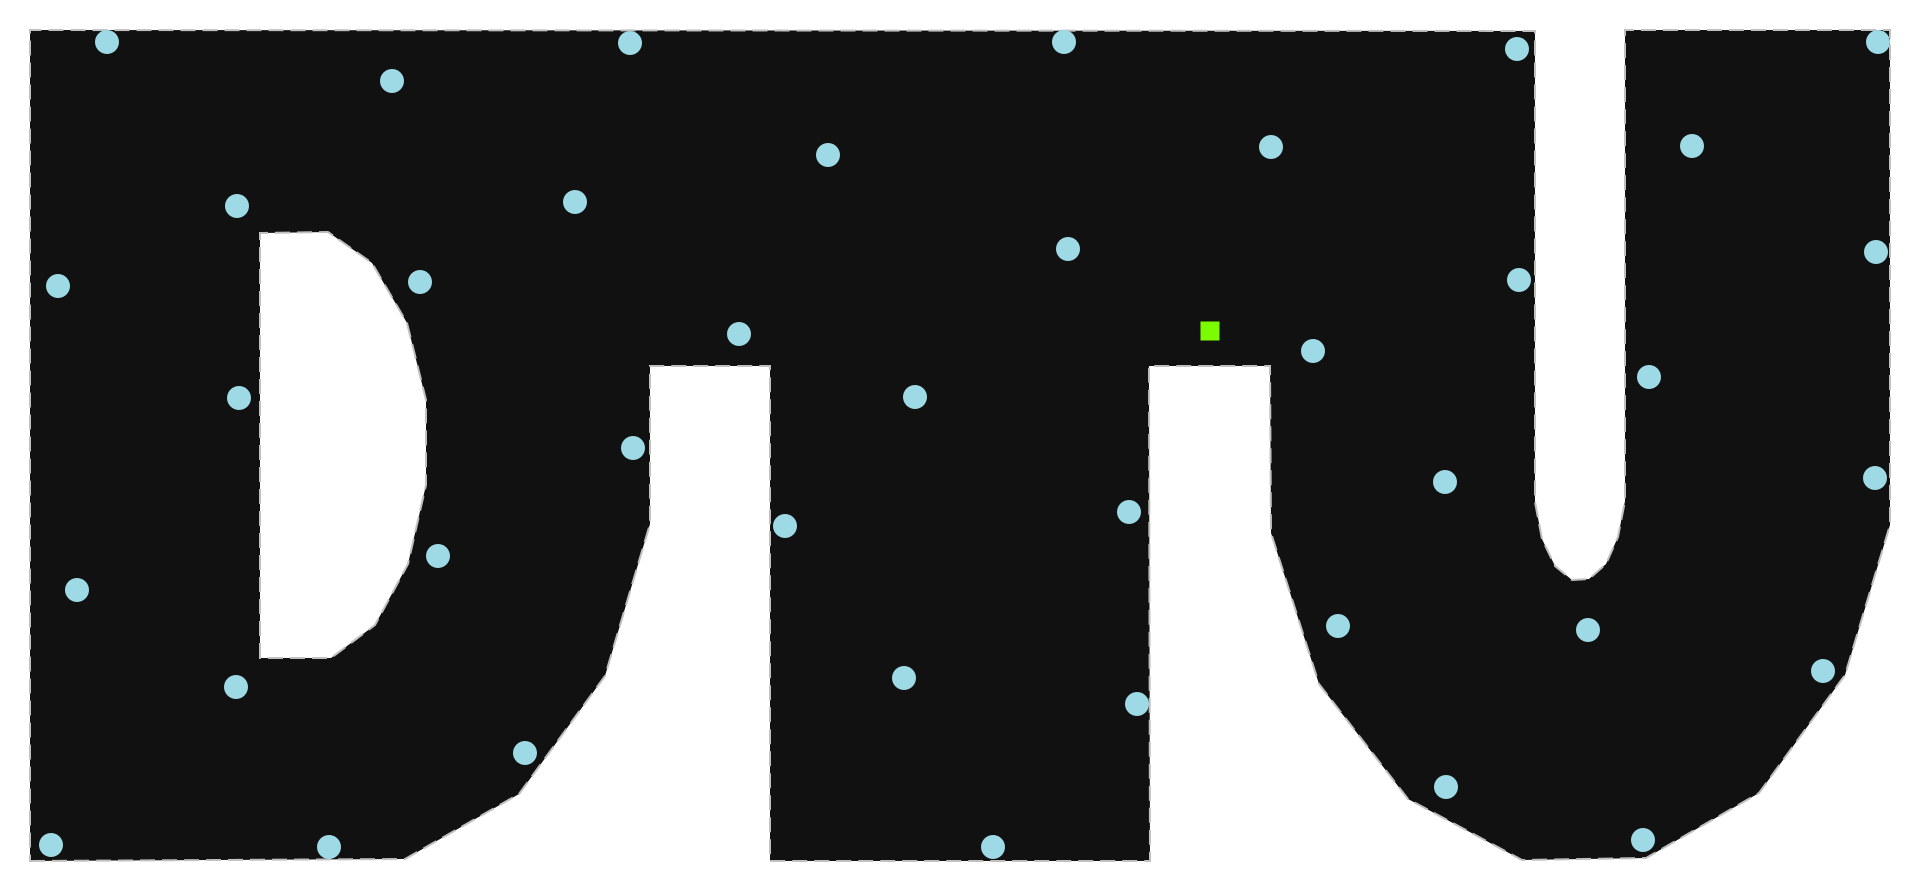

In [4]:
wfn

### Optimize

Warmstart with `EWRouter`:

>Note: In OptiWindNet, `MILPRouter` automatically uses any existing feasible network and
>checks whether it is eligible as a **warm start**for the MILP solver. To warm-start a
>newly created `WindFarmNetwork`, pre-run the optimization with a router (e.g. `EWRouter`
>or `HGSRouter`); subsequent runs with `MILPRouter` pick it up automatically. Which
>solutions are eligible for which model is summarized in
>[Warm-starting](../methods.md#warm-starting).

In [5]:
res_warmstart= wfn.optimize(router=EWRouter())

In [6]:
wfn.length()

1647.108905210097

The syntax for defining a MILPRouter is:

```python
router = MILPRouter(solver_name='ortools.cp_sat', time_limit=60, mip_gap=0.005, verbose=True)
```

The available solvers and their identifiers are listed in
[Available solvers](../methods.md#available-solvers); installation instructions are in the
[Setup](../setup.md) section. The remaining arguments (`time_limit`, `mip_gap`, `verbose`)
are the same for all solvers.

This example uses `'ortools.cp_sat'`, which is open source.

In [7]:
router = MILPRouter(solver_name='ortools.cp_sat', time_limit=60, mip_gap=0.005, verbose=True)

In [8]:
res = wfn.optimize(router=router)

IntegerBoundsPreprocessor                              1093 rows, 708 columns, 3962 entries with magnitude in [1.000000e+00, 7.000000e+00]
BoundPropagationPreprocessor                           1093 rows, 708 columns, 3962 entries with magnitude in [1.000000e+00, 7.000000e+00]
ImpliedIntegerPreprocessor                             1093 rows, 708 columns, 3962 entries with magnitude in [1.000000e+00, 7.000000e+00]
IntegerBoundsPreprocessor                              1093 rows, 708 columns, 3962 entries with magnitude in [1.000000e+00, 7.000000e+00]
ReduceCostOverExclusiveOrConstraintPreprocessor        1093 rows, 708 columns, 3962 entries with magnitude in [1.000000e+00, 7.000000e+00]

Scaling to pure integer problem.
Num integers: 708/708 (implied: 0 in_inequalities: 0 max_scaling: 0) [IP] 
Maximum constraint coefficient relative error: 0
Maximum constraint worst-case activity error: 0
Constraint scaling factor range: [1, 1]

Starting CP-SAT solver v9.15.6755
Parameters: max_time_in_

In [9]:
wfn.solution_info()

{'router': 'MILPRouter',
 'capacity': 7,
 'solver_name': 'ortools.cp_sat',
 'mip_gap': 0.005,
 'time_limit': 60,
 'topology': <Topology.BRANCHED: 'branched'>,
 'feeder_route': <FeederRoute.SEGMENTED: 'segmented'>,
 'feeder_limit': <FeederLimit.UNLIMITED: 'unlimited'>,
 'balanced': False,
 'runtime': 14.954764,
 'bound': 1575.3554353145887,
 'objective': 1575.3554359239731,
 'relgap': 3.868234621506872e-10,
 'termination': 'OPTIMAL'}

In [10]:
wfn.length()

1575.355435923973

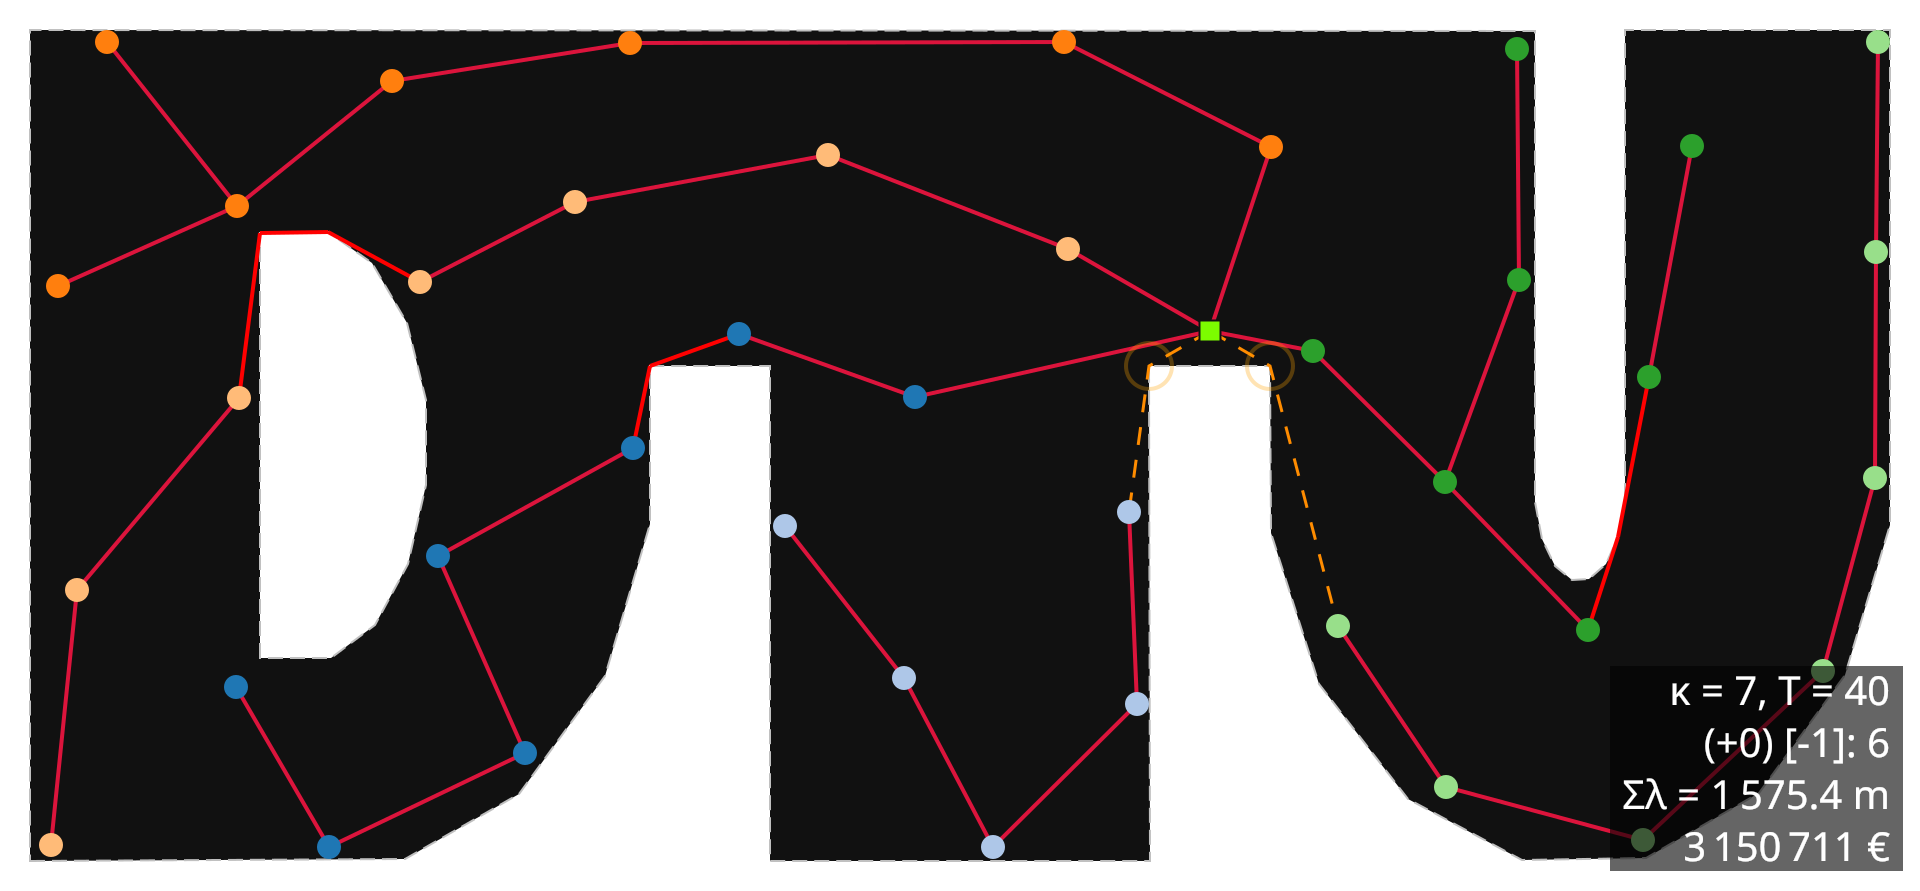

In [11]:
wfn

`MILPRouter` has two optional arguments: `model_options` (what kind of solution you want)
and `solver_options` (how long and how hard the solver searches). See
[Model options](../methods.md#model-options) and
[Solver options](../methods.md#solver-options) for the reference, and
[Setting ModelOptions and SolverOptions](hi30_options.ipynb) for worked examples.

In [12]:
from optiwindnet.api import ModelOptions
model_options = ModelOptions(
                        topology='radial',
                        feeder_limit='minimum',
                        feeder_route='segmented',
                    )
solver_options=dict(
    num_workers = 5,
)
router= MILPRouter(solver_name='ortools.cp_sat', time_limit=60, mip_gap=0.01, model_options=model_options, verbose=True)
res = wfn.optimize(router=router)

IntegerBoundsPreprocessor                              1133 rows, 708 columns, 4276 entries with magnitude in [1.000000e+00, 7.000000e+00]
BoundPropagationPreprocessor                           1133 rows, 708 columns, 4276 entries with magnitude in [1.000000e+00, 7.000000e+00]
ImpliedIntegerPreprocessor                             1133 rows, 708 columns, 4276 entries with magnitude in [1.000000e+00, 7.000000e+00]
IntegerBoundsPreprocessor                              1133 rows, 708 columns, 4276 entries with magnitude in [1.000000e+00, 7.000000e+00]
ReduceCostOverExclusiveOrConstraintPreprocessor        1133 rows, 708 columns, 4276 entries with magnitude in [1.000000e+00, 7.000000e+00]

Scaling to pure integer problem.
Num integers: 708/708 (implied: 0 in_inequalities: 0 max_scaling: 0) [IP] 
Maximum constraint coefficient relative error: 0
Maximum constraint worst-case activity error: 0
Constraint scaling factor range: [1, 1]

Starting CP-SAT solver v9.15.6755
Parameters: max_time_in_

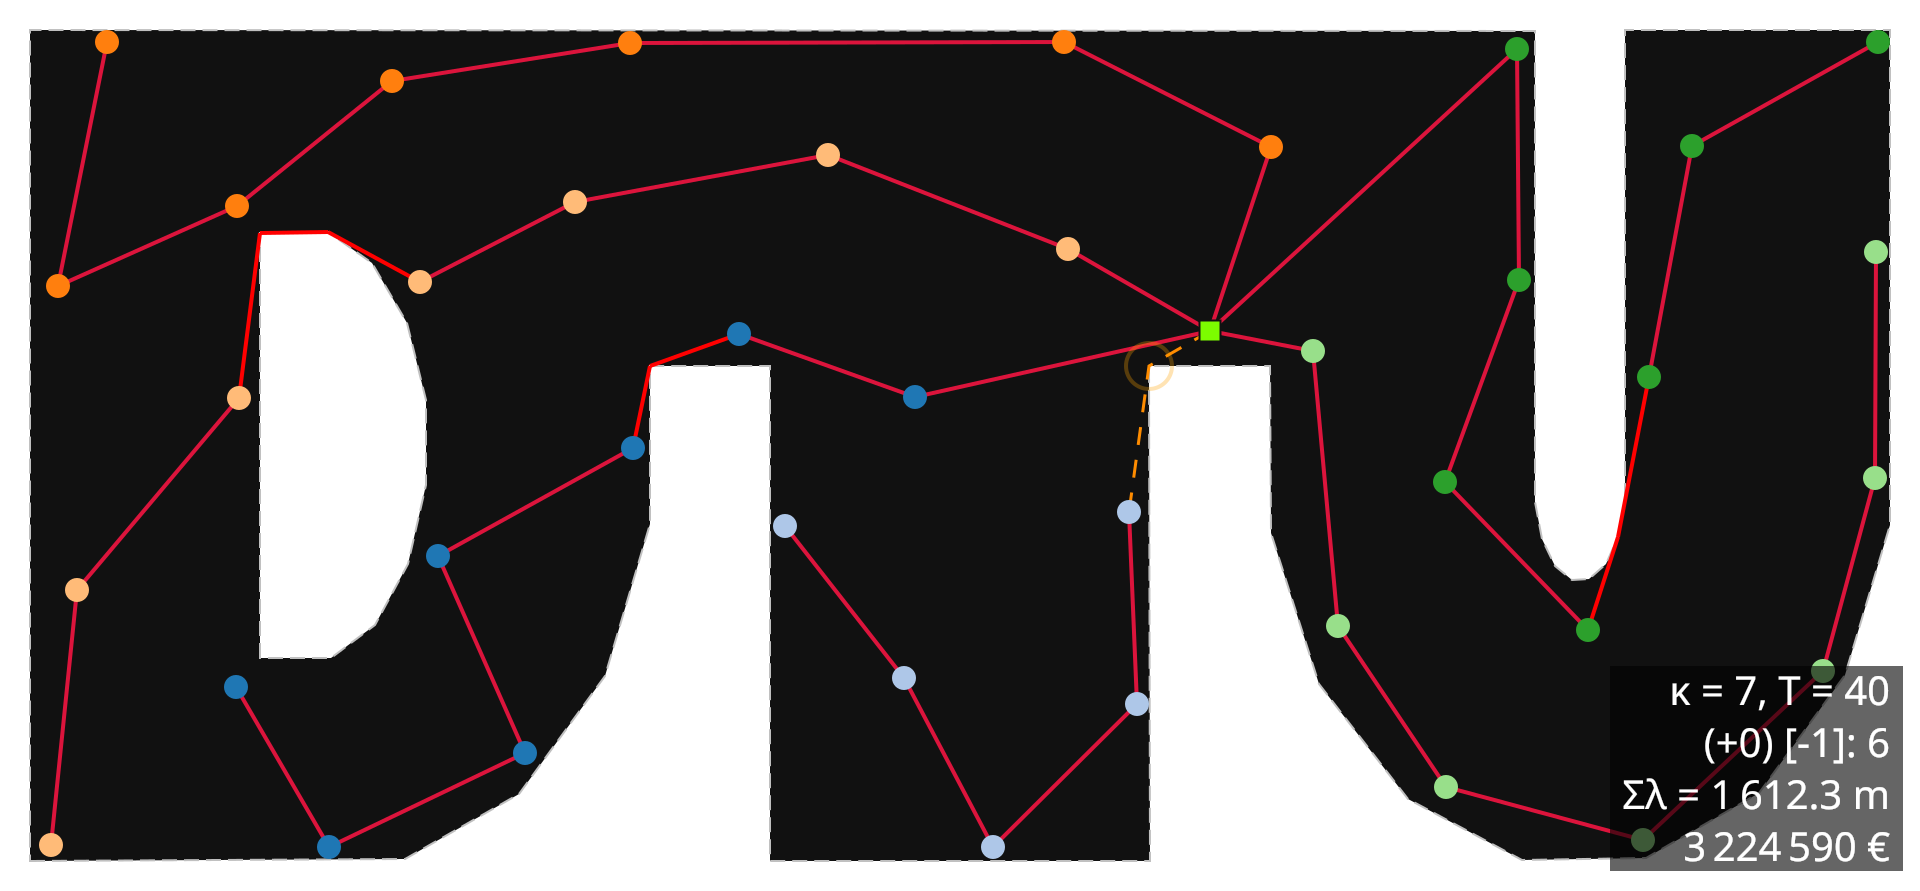

In [13]:
wfn

#### Ringed Topology with MILPRouter
We can also optimize for a **ringed topology**by setting `topology='ringed'` in `ModelOptions`:

IntegerBoundsPreprocessor                              1132 rows, 748 columns, 3962 entries with magnitude in [1.000000e+00, 1.400000e+01]
BoundPropagationPreprocessor                           1132 rows, 748 columns, 3962 entries with magnitude in [1.000000e+00, 1.400000e+01]
ImpliedIntegerPreprocessor                             1132 rows, 748 columns, 3962 entries with magnitude in [1.000000e+00, 1.400000e+01]
IntegerBoundsPreprocessor                              1132 rows, 748 columns, 3962 entries with magnitude in [1.000000e+00, 1.400000e+01]
ReduceCostOverExclusiveOrConstraintPreprocessor        1132 rows, 748 columns, 3962 entries with magnitude in [1.000000e+00, 1.400000e+01]

Scaling to pure integer problem.
Num integers: 748/748 (implied: 0 in_inequalities: 0 max_scaling: 0) [IP] 
Maximum constraint coefficient relative error: 0
Maximum constraint worst-case activity error: 0
Constraint scaling factor range: [1, 1]

Starting CP-SAT solver v9.15.6755
Parameters: max_time_in_

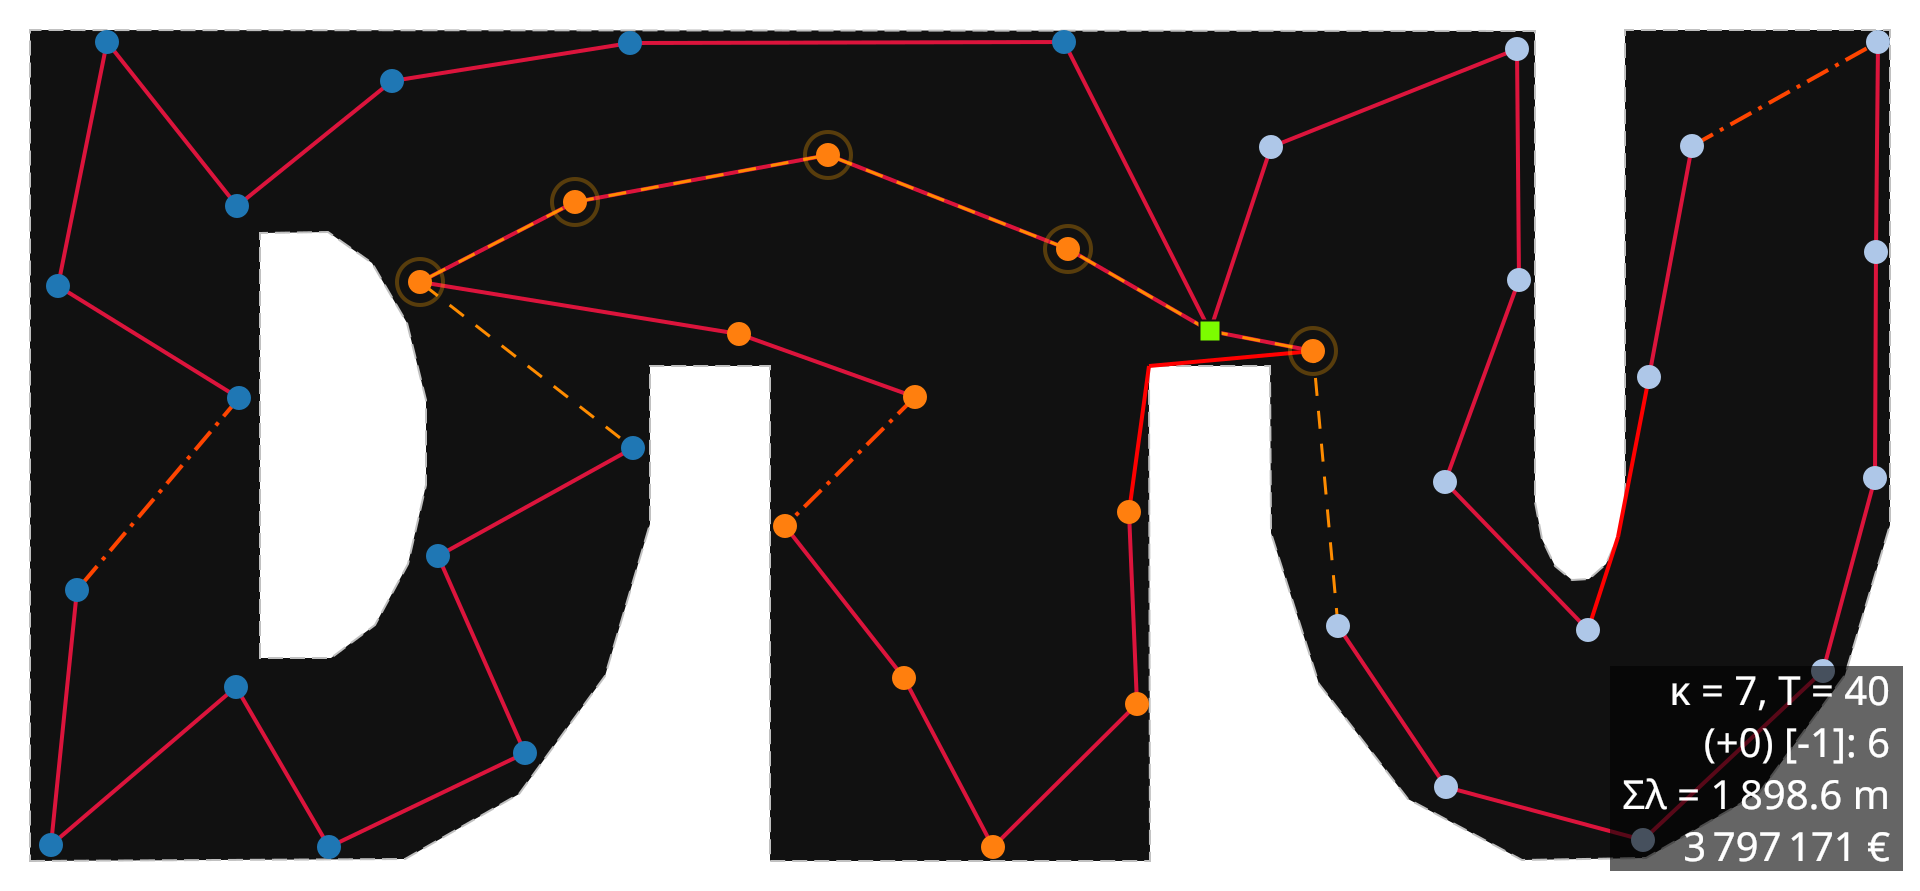

In [14]:
router_ring = MILPRouter(
    solver_name='ortools.cp_sat',
    time_limit=15,
    mip_gap=0.01,
    model_options=ModelOptions(topology='ringed', feeder_limit='minimum'),
    verbose=True,
)
res_ring = wfn.optimize(router=router_ring)
wfn